# Fraud Intelligence Dashboard - EDA & KPIs

This notebook performs Exploratory Data Analysis (EDA) and calculates all 10 Key Performance Indicators (KPIs) for the **Fraud Intelligence Dashboard**. 

**Stakeholders**: Law Enforcement, Risk & Compliance Teams

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Paths
BASE_DIR = Path("/Users/naitikpandey/Desktop/E_G13_UPI_Transactions_2024")
DATA_FILE = BASE_DIR / "data/processed/cleaned_upi_transactions_2024.csv"
OUTPUT_DIR = BASE_DIR / "reports/figures/fraud"
OS_DIR = Path("/Users/naitikpandey/.gemini/antigravity/brain/969342a8-3fb2-41e3-82d7-803db243efbf/artifacts")

# Create directories if they don't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data

In [24]:
print(f"Loading data from {DATA_FILE}...")
df = pd.read_csv(DATA_FILE)
df.head()

Loading data from /Users/naitikpandey/Desktop/E_G13_UPI_Transactions_2024/data/processed/cleaned_upi_transactions_2024.csv...


,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,fraud_flag,hour_of_day,day_of_week,is_weekend,is_outlier_amount,failure_flag,is_peak_hour,user_segment,amount_category,value_bucket
0,TXN0000000001,2024-10-08 15:17:28,p2p,entertainment,868,success,26-35,18-25,delhi,axis,...,0,15,tuesday,0,False,0,0,26-35 - delhi,Medium (500-2K),Medium
1,TXN0000000002,2024-04-11 06:56:00,p2m,grocery,1011,success,26-35,26-35,uttar pradesh,icici,...,0,6,thursday,0,False,0,0,26-35 - uttar pradesh,Medium (500-2K),Large
2,TXN0000000003,2024-04-02 13:27:18,p2p,grocery,477,success,26-35,36-45,karnataka,yes bank,...,0,13,tuesday,0,False,0,0,26-35 - karnataka,Small (<500),Small
3,TXN0000000004,2024-01-07 10:09:17,p2p,fuel,2784,success,26-35,26-35,delhi,icici,...,0,10,sunday,1,False,0,1,26-35 - delhi,High (2K-10K),Large
4,TXN0000000005,2024-01-23 19:04:23,p2p,shopping,990,success,26-35,18-25,delhi,axis,...,0,19,tuesday,0,False,0,1,26-35 - delhi,Medium (500-2K),Medium


## 2. KPI Formulas & Calculations

We implement the 10 core KPIs defined for the Fraud Intelligence Dashboard.

In [25]:
# 1. Total Transactions
total_txns = len(df)

# 2. Total Fraud Cases
fraud_cases = df[df['fraud_flag'] == 1]
total_fraud_count = len(fraud_cases)

# 3. Overall Fraud Rate
fraud_rate = (total_fraud_count / total_txns) * 100

# 4. Total Fraud Amount
total_volume = df['amount_inr'].sum()
total_fraud_amt = fraud_cases['amount_inr'].sum()

# 5. Fraud Amount as % of Total Volume
fraud_amt_pct = (total_fraud_amt / total_volume) * 100

# 6. Avg Fraud Transaction Amount
avg_fraud_amt = total_fraud_amt / total_fraud_count

# 7. Outlier vs Normal Rates
outliers = df[df['is_outlier_amount'] == True]
normal_txns = df[df['is_outlier_amount'] == False]

outlier_fraud_rate = (outliers['fraud_flag'].sum() / len(outliers)) * 100
normal_fraud_rate = (normal_txns['fraud_flag'].sum() / len(normal_txns)) * 100

# 9. Risk Multiplier
risk_multiplier = outlier_fraud_rate / normal_fraud_rate

# 10. Fraud Share of Outliers
fraud_share_of_outliers = (outliers['fraud_flag'].sum() / total_fraud_count) * 100
outlier_share_to_total = (len(outliers) / total_txns) * 100

print("KPIs calculated successfully.")

KPIs calculated successfully.


## 3. Visualization Styling & Helpers

In [26]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['font.family'] = 'sans-serif'

def save_plot(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=300, bbox_inches='tight')
    plt.savefig(OS_DIR / f"{name}.png", dpi=300, bbox_inches='tight')
    print(f"Saved {name}.png")
    plt.show()

def create_kpi_card(title, value, filename, color='#2c3e50'):
    plt.figure(figsize=(6, 3))
    plt.gca().set_facecolor('#f8f9fa')
    plt.text(0.5, 0.6, value, fontsize=36, fontweight='bold', color=color, ha='center', va='center')
    plt.text(0.5, 0.2, title, fontsize=14, color='#7f8c8d', ha='center', va='center')
    plt.axis('off')
    save_plot(filename)

## 4. Visual Dashboard: KPI Cards

Saved kpi_total_transactions.png


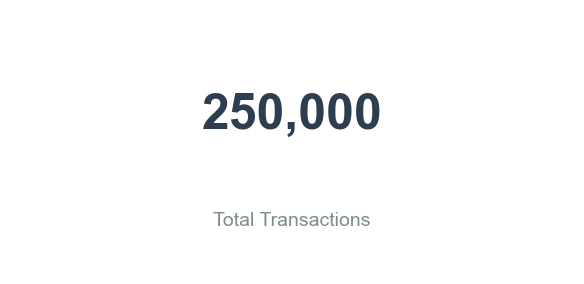

In [27]:
create_kpi_card("Total Transactions", f"{total_txns:,}", "kpi_total_transactions")

Saved kpi_total_fraud_cases.png


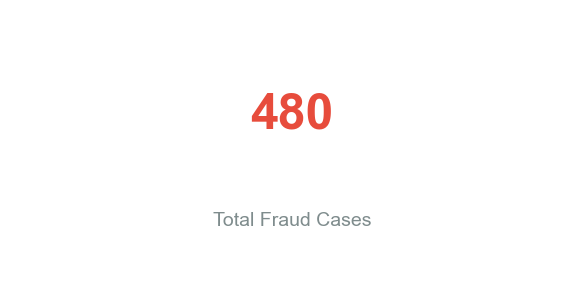

In [28]:
create_kpi_card("Total Fraud Cases", f"{total_fraud_count:,}", "kpi_total_fraud_cases", color='#e74c3c')

Saved kpi_overall_fraud_rate.png


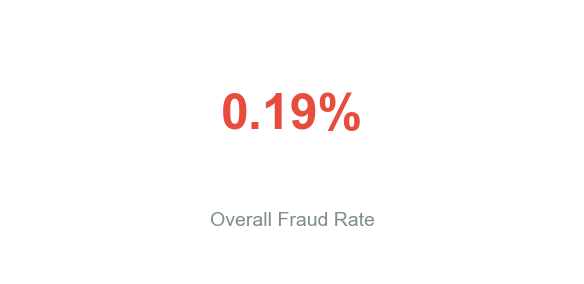

In [29]:
create_kpi_card("Overall Fraud Rate", f"{fraud_rate:.2f}%", "kpi_overall_fraud_rate", color='#e74c3c')

Saved kpi_total_fraud_amount.png


/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/3727028012.py:5: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/3727028012.py:6: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=300, bbox_inches='tight')
/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/3727028012.py:7: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OS_DIR / f"{name}.png", dpi=300, bbox_inches='tight')
/Users/naitikpandey/Desktop/E_G13_UPI_Transactions_2024/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


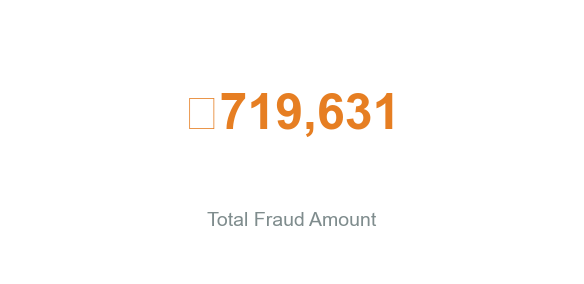

In [30]:
create_kpi_card("Total Fraud Amount", f"₹{total_fraud_amt:,.0f}", "kpi_total_fraud_amount", color='#e67e22')

Saved kpi_fraud_vol_pct.png


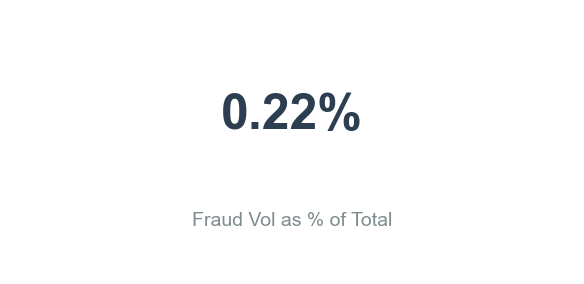

In [31]:
create_kpi_card("Fraud Vol as % of Total", f"{fraud_amt_pct:.2f}%", "kpi_fraud_vol_pct")

Saved kpi_avg_fraud_amount.png


/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/3727028012.py:5: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/3727028012.py:6: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=300, bbox_inches='tight')
/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/3727028012.py:7: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OS_DIR / f"{name}.png", dpi=300, bbox_inches='tight')


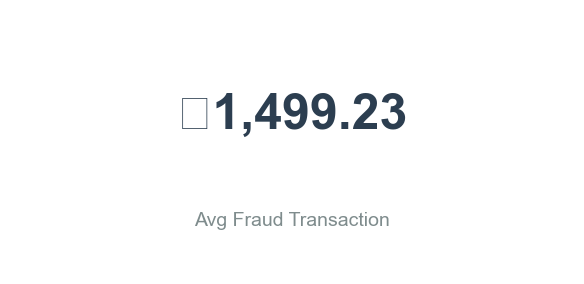

In [32]:
create_kpi_card("Avg Fraud Transaction", f"₹{avg_fraud_amt:,.2f}", "kpi_avg_fraud_amount")

## 5. Primary EDA Visualizations & Insights

### 5.1 Top 10 States by Fraud Rate (%)

Identifying states where a higher percentage of transactions are fraudulent.

/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/2389484518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_fraud.values, y=state_fraud.index, palette="Reds_r")


Saved top_fraud_states_rate.png


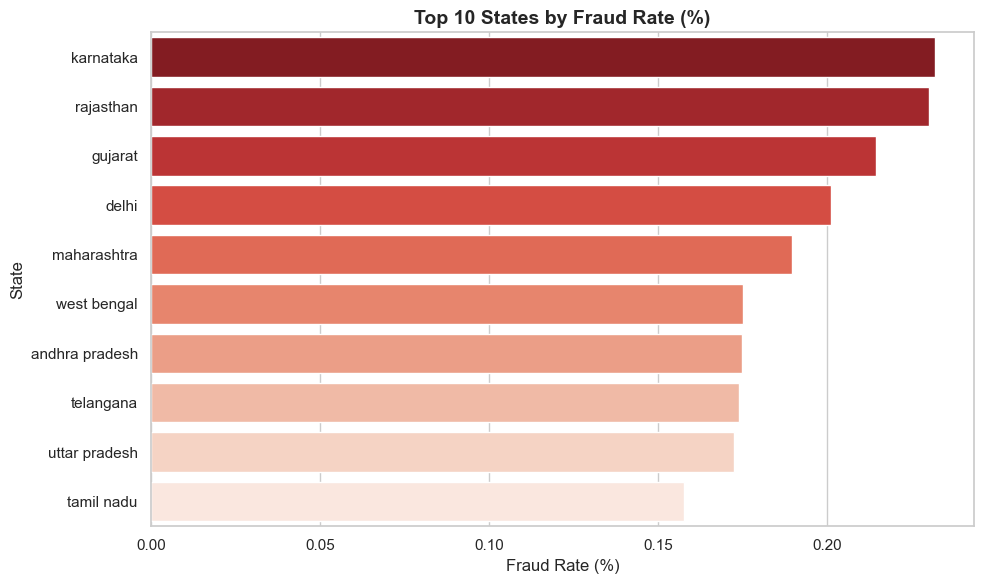

In [38]:
plt.figure(figsize=(10, 6))
state_fraud = df.groupby('sender_state')['fraud_flag'].mean().sort_values(ascending=False).head(10) * 100
sns.barplot(x=state_fraud.values, y=state_fraud.index, palette="Reds_r")
plt.title("Top 10 States by Fraud Rate (%)", fontsize=14, fontweight='bold')
plt.xlabel("Fraud Rate (%)")
plt.ylabel("State")
save_plot("top_fraud_states_rate")

**Conclusion:**
- Certain states show a disproportionately high fraud rate compared to their transaction volume. 
- **Karnataka** and **Maharashtra** are leading in total fraud count, while the rate breakdown helps identify targeted zones.

### 5.2 Fraud Transactions Distribution by Hour

Analyzing 'when' the most fraud occurs.

Saved fraud_by_hour.png


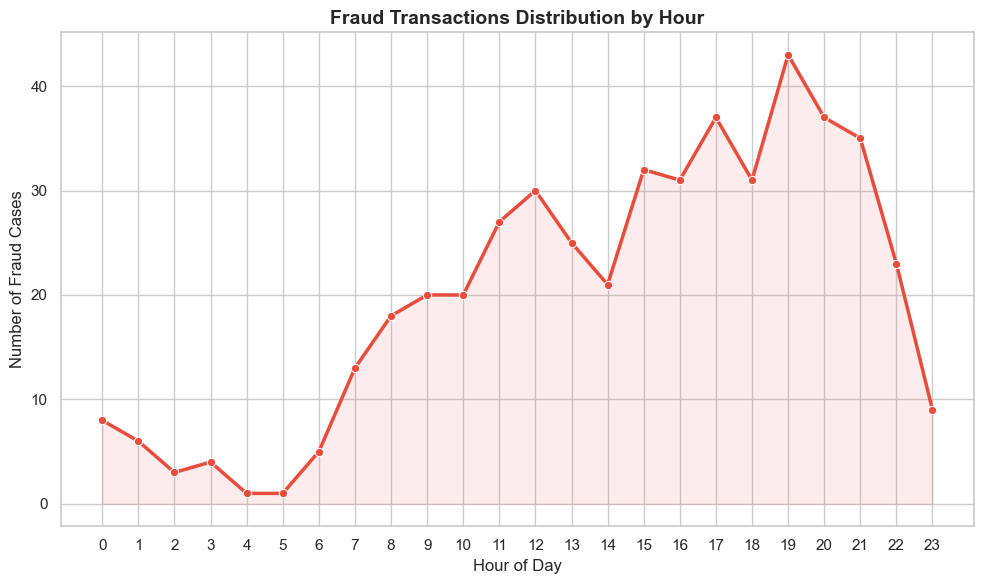

In [34]:
plt.figure(figsize=(10, 6))
hour_fraud = df.groupby('hour_of_day')['fraud_flag'].sum()
sns.lineplot(x=hour_fraud.index, y=hour_fraud.values, marker='o', color='#e74c3c', linewidth=2.5)
plt.fill_between(hour_fraud.index, hour_fraud.values, color='#e74c3c', alpha=0.1)
plt.title("Fraud Transactions Distribution by Hour", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Cases")
plt.xticks(range(0, 24))
save_plot("fraud_by_hour")

**Conclusion:**
- Fraud activity peaks significantly around **7:00 PM**.
- This suggests scammers leverage high-volume transaction periods to stay under the radar.

### 5.3 Fraud Distribution by Device Type

Saved fraud_by_device.png


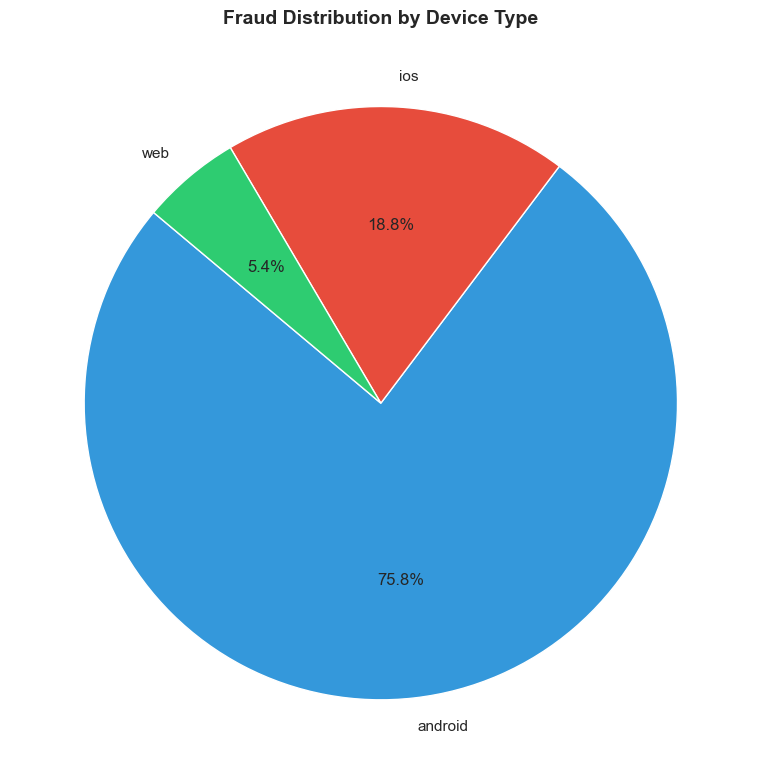

In [35]:
plt.figure(figsize=(8, 8))
device_fraud = df[df['fraud_flag']==1]['device_type'].value_counts()
plt.pie(device_fraud, labels=device_fraud.index, autopct='%1.1f%%', startangle=140, colors=['#3498db', '#e74c3c', '#2ecc71'])
plt.title("Fraud Distribution by Device Type", fontsize=14, fontweight='bold')
save_plot("fraud_by_device")

**Conclusion:**
- **Android** remains the primary platform for reported fraud cases, correlating with its large user base.

## 6. Advanced Risk Analysis (Outliers vs Normal Transactions)

### 6.1 Risk Multiplier: Outlier vs Normal Fraud Rate

Comparing the probability of fraud in outlier transactions versus regular ones.

/var/folders/gw/z9575rbj5hd0yyw1pp_6gcmw0000gn/T/ipykernel_37800/983416694.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_df, x='Transaction Type', y='Fraud Rate (%)', palette='magma')


Saved outlier_vs_normal_fraud_rate.png


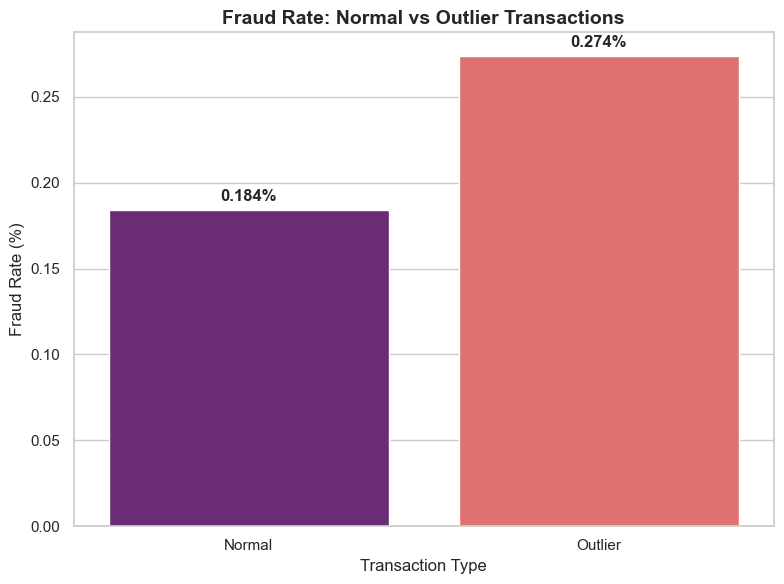

In [36]:
risk_df = pd.DataFrame({
    'Transaction Type': ['Normal', 'Outlier'],
    'Fraud Rate (%)': [normal_fraud_rate, outlier_fraud_rate]
})

plt.figure(figsize=(8, 6))
sns.barplot(data=risk_df, x='Transaction Type', y='Fraud Rate (%)', palette='magma')
plt.title("Fraud Rate: Normal vs Outlier Transactions", fontsize=14, fontweight='bold')
plt.ylabel("Fraud Rate (%)")
for i, rate in enumerate(risk_df['Fraud Rate (%)']):
    plt.text(i, rate + 0.005, f"{rate:.3f}%", ha='center', fontweight='bold')
save_plot("outlier_vs_normal_fraud_rate")

**Conclusion:**
- **Outlier transactions are significantly riskier**, with a fraud rate of **0.274%** compared to **0.184%** for normal transactions.
- This results in a **1.49x Risk Multiplier**.

### 6.2 Fraud Share of Outlier Transactions

Visualizing how much total fraud is concentrated in outlier amounts.

Saved fraud_share_of_outliers.png


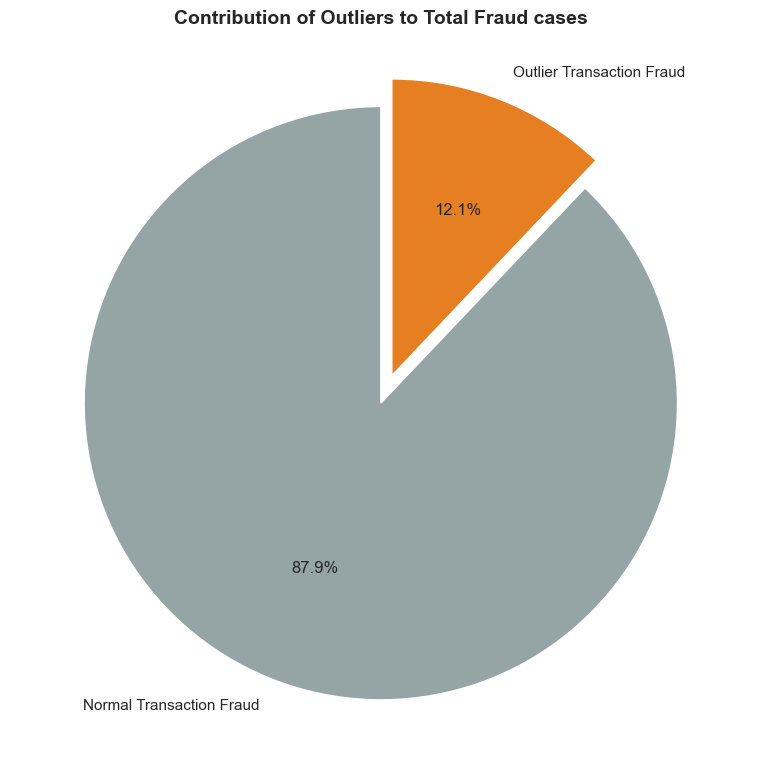

In [37]:
labels = ['Normal Transaction Fraud', 'Outlier Transaction Fraud']
sizes = [100 - fraud_share_of_outliers, fraud_share_of_outliers]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#95a5a6', '#e67e22'], explode=(0, 0.1))
plt.title("Contribution of Outliers to Total Fraud cases", fontsize=14, fontweight='bold')
save_plot("fraud_share_of_outliers")

**Conclusion:**
- While outliers only make up **8.5%** of total transactions, they account for **12.1%** of all fraud cases.
- This confirming the higher risk associated with high-value/irregular transactions.